# Mendeley → YOLO format + merge com HF filtrado

Converte o dataset Mendeley (máscaras binárias) pra formato YOLO (polígonos),
mapeia classes pros IDs novos (0-20), e junta com o HF filtrado.

**Resultado final:** dataset unificado com 21 classes brasileiras core.

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, shutil
from pathlib import Path

# Caminhos
HF_FILTERED_ZIP = '/content/drive/MyDrive/nutrition_planner/dataset_filtered.zip'
MENDELEY_ZIP = '/content/drive/MyDrive/nutrition_planner/mendeley.zip'

# Descompacta HF filtrado
if not os.path.exists('/content/dataset_filtered/data'):
    !mkdir -p /content/dataset_filtered
    !unzip -q -o {HF_FILTERED_ZIP} -d /content/dataset_filtered/

# Descompacta Mendeley
if not os.path.exists('/content/mendeley'):
    !mkdir -p /content/mendeley
    !unzip -q -o {MENDELEY_ZIP} -d /content/mendeley/

print("✅ Datasets descompactados")
!ls /content/dataset_filtered/data/
!ls /content/mendeley/

✅ Datasets descompactados
dataset.yaml  images  labels
'Brazilian food images'   __MACOSX


## 2. Definir mapeamento Mendeley → suas classes

In [3]:
# Mesma lista de classes do filter_hf
FINAL_CLASSES = [
    'arroz',         # 0
    'feijão',        # 1
    'frango',        # 2
    'carne bovina',  # 3
    'peixe',         # 4
    'ovo',           # 5
    'carne suína',   # 6
    'batata frita',  # 7
    'batata cozida', # 8
    'purê',          # 9
    'farofa',        # 10
    'mandioca',      # 11
    'macarrão',      # 12
    'pão',           # 13
    'salada',        # 14
    'tomate',        # 15
    'cenoura',       # 16
    'brócolis',      # 17
    'repolho',       # 18
    'abóbora',       # 19
    'pizza',         # 20
]
pt_to_id = {pt: i for i, pt in enumerate(FINAL_CLASSES)}

# Mendeley pasta name → classe PT
# Classes do Mendeley: beans, beef, beet, cabbage, carrot, cassava, chicken,
#                     corn, egg, farofa, fries, mashed, mayo(potato salad),
#                     milanesesteak, noodles, pastaredsauce, pumpkin, rice, salad, tomato
MENDELEY_TO_PT = {
    'beans': 'feijão',
    'beef': 'carne bovina',
    'cabbage': 'repolho',
    'carrot': 'cenoura',
    'cassava': 'mandioca',
    'chicken': 'frango',
    'egg': 'ovo',
    'farofa': 'farofa',
    'fries': 'batata frita',
    'mashed': 'purê',
    'milanesesteak': 'carne bovina',  # bife à milanesa = carne bovina
    'noodles': 'macarrão',
    'pastaredsauce': 'macarrão',  # macarrão ao molho = macarrão
    'pumpkin': 'abóbora',
    'rice': 'arroz',
    'salad': 'salada',
    'tomato': 'tomate',
    # Sem mapeamento (sai do dataset):
    # 'beet' (beterraba) → não é classe nossa
    # 'corn' (milho) → não é classe nossa
    # 'mayo(potato salad)' → não é classe nossa
}

print("Mapeamento Mendeley → suas classes:")
for mend, pt in MENDELEY_TO_PT.items():
    print(f"  {mend:25s} → {pt} (ID {pt_to_id[pt]})")

print(f"\nClasses do Mendeley sem mapeamento (serão ignoradas): beet, corn, mayo(potato salad)")

Mapeamento Mendeley → suas classes:
  beans                     → feijão (ID 1)
  beef                      → carne bovina (ID 3)
  cabbage                   → repolho (ID 18)
  carrot                    → cenoura (ID 16)
  cassava                   → mandioca (ID 11)
  chicken                   → frango (ID 2)
  egg                       → ovo (ID 5)
  farofa                    → farofa (ID 10)
  fries                     → batata frita (ID 7)
  mashed                    → purê (ID 9)
  milanesesteak             → carne bovina (ID 3)
  noodles                   → macarrão (ID 12)
  pastaredsauce             → macarrão (ID 12)
  pumpkin                   → abóbora (ID 19)
  rice                      → arroz (ID 0)
  salad                     → salada (ID 14)
  tomato                    → tomate (ID 15)

Classes do Mendeley sem mapeamento (serão ignoradas): beet, corn, mayo(potato salad)


## 3. Converter máscaras binárias → polígonos YOLO

Lê cada máscara binária do Mendeley, encontra contornos com OpenCV e
escreve labels no formato YOLO (class_id + polígono normalizado).

In [4]:
import cv2
import numpy as np
from PIL import Image
from tqdm import tqdm

MENDELEY_ROOT = '/content/mendeley/Brazilian food images/training_set'

def mask_to_yolo_polygon(mask_path, class_id, min_area=100):
    """Converte máscara binária em uma ou mais linhas de label YOLO.
    Retorna lista de strings (uma por contorno encontrado)."""
    mask = np.array(Image.open(mask_path).convert('L'))
    h, w = mask.shape
    binary = (mask > 127).astype(np.uint8)
    
    # Encontra contornos
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    lines = []
    for cnt in contours:
        if cv2.contourArea(cnt) < min_area:
            continue  # ignora contornos minúsculos
        
        # Simplifica polígono (reduz pontos pra ficar parecido com YOLO)
        epsilon = 0.005 * cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, epsilon, True)
        
        if len(approx) < 3:
            continue  # polígono precisa de pelo menos 3 pontos
        
        # Normaliza coordenadas
        coords = []
        for point in approx:
            x, y = point[0]
            coords.append(f"{x/w:.6f}")
            coords.append(f"{y/h:.6f}")
        
        line = f"{class_id} " + " ".join(coords)
        lines.append(line)
    
    return lines


# Processa todos os pares do Mendeley
import random
random.seed(42)

# Coletar todos pares (image, mask, class_id)
all_samples = []
for mend_class in os.listdir(MENDELEY_ROOT):
    if mend_class not in MENDELEY_TO_PT:
        continue
    pt_class = MENDELEY_TO_PT[mend_class]
    class_id = pt_to_id[pt_class]
    
    cls_dir = f'{MENDELEY_ROOT}/{mend_class}'
    files = sorted(os.listdir(cls_dir))
    
    for f in files:
        if not f.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        stem, ext = os.path.splitext(f)
        if stem.endswith('_'):
            continue  # é máscara, ignora
        mask_name = f'{stem}_{ext}'
        if os.path.exists(f'{cls_dir}/{mask_name}'):
            all_samples.append({
                'img': f'{cls_dir}/{f}',
                'mask': f'{cls_dir}/{mask_name}',
                'class_id': class_id,
                'class_pt': pt_class,
            })

print(f"Total de pares válidos: {len(all_samples)}")

# Split 80/20
random.shuffle(all_samples)
n_train = int(len(all_samples) * 0.8)
train_samples = all_samples[:n_train]
val_samples = all_samples[n_train:]
print(f"Train: {len(train_samples)}, Val: {len(val_samples)}")

Total de pares válidos: 847
Train: 677, Val: 170


In [5]:
# Converte e salva no formato YOLO
OUT_ROOT = Path('/content/mendeley_yolo')
for split in ['train', 'val']:
    (OUT_ROOT / 'images' / split).mkdir(parents=True, exist_ok=True)
    (OUT_ROOT / 'labels' / split).mkdir(parents=True, exist_ok=True)

def process_split(samples, split_name):
    n_ok = 0
    n_skip = 0
    for i, s in enumerate(tqdm(samples, desc=split_name)):
        # Nome único pra evitar colisão
        out_stem = f"mend_{split_name}_{i:05d}"
        out_img = OUT_ROOT / 'images' / split_name / f'{out_stem}.jpg'
        out_lbl = OUT_ROOT / 'labels' / split_name / f'{out_stem}.txt'
        
        # Converte máscara em polígono(s)
        lines = mask_to_yolo_polygon(s['mask'], s['class_id'])
        if not lines:
            n_skip += 1
            continue
        
        # Salva
        shutil.copy(s['img'], out_img)
        with open(out_lbl, 'w') as f:
            f.write("\n".join(lines) + "\n")
        n_ok += 1
    
    print(f"  {split_name}: {n_ok} ok, {n_skip} pulados (máscaras ruins)")
    return n_ok

n_train_ok = process_split(train_samples, 'train')
n_val_ok = process_split(val_samples, 'val')

train: 100%|██████████| 677/677 [00:02<00:00, 248.72it/s]


  train: 677 ok, 0 pulados (máscaras ruins)


val: 100%|██████████| 170/170 [00:00<00:00, 245.51it/s]

  val: 170 ok, 0 pulados (máscaras ruins)


## 4. Visualizar conversão (sanity check)

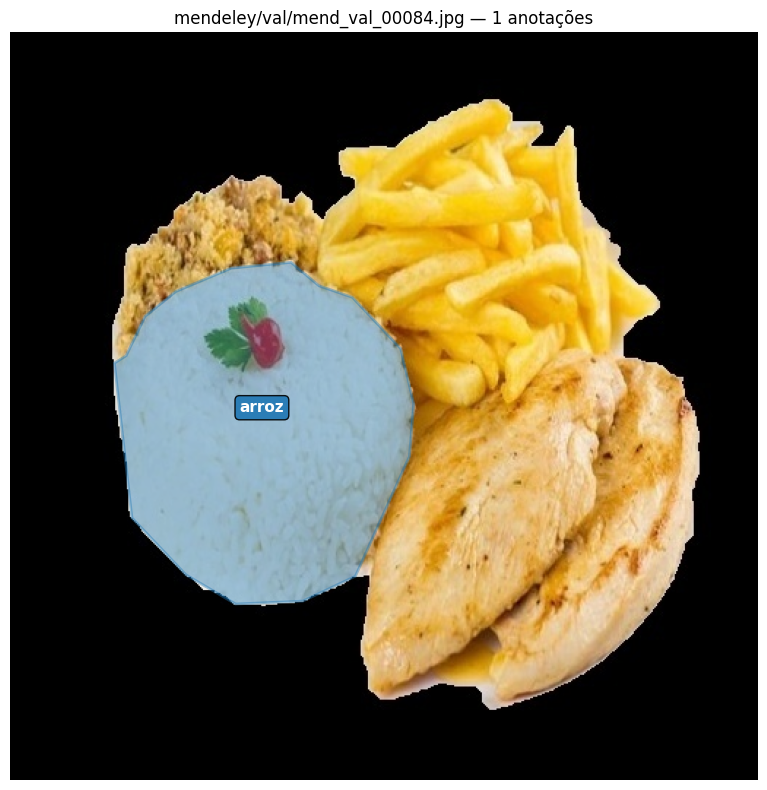

Classes: ['arroz']


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_mendeley_sample(split='val', idx=None):
    img_dir = OUT_ROOT / 'images' / split
    lbl_dir = OUT_ROOT / 'labels' / split
    
    images = sorted(os.listdir(img_dir))
    if idx is None:
        idx = random.randint(0, len(images) - 1)
    
    img_name = images[idx]
    stem = os.path.splitext(img_name)[0]
    img = Image.open(img_dir / img_name).convert('RGB')
    w, h = img.size
    
    annotations = []
    lbl_path = lbl_dir / f'{stem}.txt'
    if lbl_path.exists():
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 7:
                    continue
                cls_id = int(parts[0])
                coords = list(map(float, parts[1:]))
                points = [(coords[i]*w, coords[i+1]*h) for i in range(0, len(coords), 2)]
                annotations.append((cls_id, points))
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(img)
    
    colors = plt.cm.tab20(np.linspace(0, 1, 21))
    for cls_id, points in annotations:
        poly = patches.Polygon(points, closed=True, fill=True, 
                              facecolor=colors[cls_id], alpha=0.4,
                              edgecolor=colors[cls_id], linewidth=2)
        ax.add_patch(poly)
        cx = sum(p[0] for p in points) / len(points)
        cy = sum(p[1] for p in points) / len(points)
        ax.text(cx, cy, FINAL_CLASSES[cls_id], color='white', fontsize=11,
               weight='bold', ha='center', va='center',
               bbox=dict(boxstyle='round', facecolor=colors[cls_id], alpha=0.9))
    
    ax.set_title(f'mendeley/{split}/{img_name} — {len(annotations)} anotações')
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    
    print(f"Classes: {[FINAL_CLASSES[c] for c, _ in annotations]}")

visualize_mendeley_sample('val')

## 5. Merge HF filtrado + Mendeley convertido

Combina os dois datasets numa única pasta com a mesma estrutura.

In [ ]:
MERGED_ROOT = Path('/content/dataset_merged/data')
for split in ['train', 'val']:
    (MERGED_ROOT / 'images' / split).mkdir(parents=True, exist_ok=True)
    (MERGED_ROOT / 'labels' / split).mkdir(parents=True, exist_ok=True)

# Copia HF filtrado
HF_ROOT = Path('/content/dataset_filtered/data')
for split in ['train', 'val']:
    src_imgs = HF_ROOT / 'images' / split
    src_lbls = HF_ROOT / 'labels' / split
    dst_imgs = MERGED_ROOT / 'images' / split
    dst_lbls = MERGED_ROOT / 'labels' / split
    
    print(f"Copiando HF {split}...")
    for f in tqdm(os.listdir(src_imgs)):
        shutil.copy(src_imgs / f, dst_imgs / f)
    for f in os.listdir(src_lbls):
        shutil.copy(src_lbls / f, dst_lbls / f)

# Copia Mendeley convertido (nomes já têm prefixo 'mend_' pra não colidir)
for split in ['train', 'val']:
    src_imgs = OUT_ROOT / 'images' / split
    src_lbls = OUT_ROOT / 'labels' / split
    dst_imgs = MERGED_ROOT / 'images' / split
    dst_lbls = MERGED_ROOT / 'labels' / split
    
    print(f"Copiando Mendeley {split}...")
    for f in os.listdir(src_imgs):
        shutil.copy(src_imgs / f, dst_imgs / f)
    for f in os.listdir(src_lbls):
        shutil.copy(src_lbls / f, dst_lbls / f)

# Cria dataset.yaml final
yaml_content = f"""path: /content/dataset_merged/data
train: images/train
val: images/val

nc: {len(FINAL_CLASSES)}
names: {FINAL_CLASSES}
"""

with open(MERGED_ROOT / 'dataset.yaml', 'w') as f:
    f.write(yaml_content)

# Conta total
for split in ['train', 'val']:
    n = len(os.listdir(MERGED_ROOT / 'images' / split))
    print(f"\n{split}: {n} imagens")

## 6. Distribuição final por classe

In [ ]:
from collections import Counter

for split in ['train', 'val']:
    counter = Counter()
    lbl_dir = MERGED_ROOT / 'labels' / split
    for lbl_file in os.listdir(lbl_dir):
        with open(lbl_dir / lbl_file) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    counter[int(parts[0])] += 1
    
    print(f"\n{split.upper()}:")
    for cls_id in range(len(FINAL_CLASSES)):
        n = counter.get(cls_id, 0)
        bar = '█' * min(n // 30, 40)
        marker = ' ❌' if n < 50 else (' ⚠️' if n < 200 else ' ✅')
        print(f"  {cls_id:2d} {FINAL_CLASSES[cls_id]:15s} {n:5d}{marker}  {bar}")

## 7. Salvar no Drive

In [ ]:
!cd /content/dataset_merged && zip -qr /content/dataset_merged.zip data/
shutil.copy('/content/dataset_merged.zip', '/content/drive/MyDrive/nutrition_planner/dataset_merged.zip')
print("✅ Salvo em /content/drive/MyDrive/nutrition_planner/dataset_merged.zip")